# R07 - Predictions with Random Forest Regression

In [228]:
# Import libraries and set a random state
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time
import lime, shap
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, cross_validate, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')
# random_state = random.randint(1,30)
random_state = 8;  dropna_type = 1;  subset_type = 1;  column_type = 15;  cv_fold = 10

In [229]:
# Read the salary dataset, drop 'id' duplicates
salaries = pd.read_csv('Salaries_v4_202412161100(expanded).csv')
# salaries = pd.read_csv('Salaries_v3_202410141100(expanded_3).csv')
# salaries = pd.read_csv('Salaries_v3_202410141100(expanded_2).csv')
# salaries = pd.read_csv('Salaries_v3_202410141100(expanded).csv')
# salaries = pd.read_csv('Salaries_v3_202408271150(expanded).csv')
# salaries = pd.read_csv('Salaries_v3_202408021730(expanded).csv')
# salaries = pd.read_csv('Salaries_v3_202402121435.csv')
# salaries = pd.read_csv('Salaries_v3_202401081515.csv')
salaries = salaries.drop_duplicates('id').reset_index()
salaries = salaries.drop(['index','Unnamed: 0'],axis=1)
print("### COUNTS OF MISSING VALUES FOR DEFAULT COLUMNS ###")
print(salaries.isnull().sum()[:16])

### COUNTS OF MISSING VALUES FOR DEFAULT COLUMNS ###
id                      0
found_country           0
title                  12
position                0
employment_type      7157
company              2618
company_score        3815
edu_degrees           554
edu_degrees_major     931
working_year            0
education_score      4598
ms_counts               0
skill_counts            0
main_skills             0
skills                  0
amount_usd              0
dtype: int64


## Select Dropping of Missing Values Strategy

In [230]:
if dropna_type == 1:    print("ROWS WITH MISSING VALUES ARE NOT DROPPED");  
elif dropna_type == 2:  print("DROPPED ALL ROWS WITH MISSING VALUES");  salaries.dropna(inplace=True)
elif dropna_type == 3:  print("DROPPED ROWS WITH MISSING found_country");  salaries.dropna(subset=['found_country'], inplace=True)
elif dropna_type == 4:  print("DROPPED ROWS WITH MISSING title");  salaries.dropna(subset=['title'], inplace=True)
elif dropna_type == 5:  
    print("DROPPED ROWS WITH MISSING employment_type");  salaries.dropna(axis=0, subset=['employment_type'], inplace=True)
elif dropna_type == 6:  print("DROPPED ROWS WITH MISSING company");  salaries.dropna(axis=0, subset=['company'], inplace=True)
elif dropna_type == 7:  
    print("DROPPED ROWS WITH MISSING company_score");  salaries.dropna(axis=0, subset=['company_score'], inplace=True)
elif dropna_type == 8:  print("DROPPED ROWS WITH MISSING edu_degrees");  salaries.dropna(axis=0, subset=['edu_degrees'], inplace=True)
elif dropna_type == 9:  
    print("DROPPED ROWS WITH MISSING edu_degrees_major");  salaries.dropna(axis=0, subset=['edu_degrees_major'], inplace=True)
elif dropna_type == 10:  
    print("DROPPED ROWS WITH MISSING education_score");  salaries.dropna(axis=0, subset=['education_score'], inplace=True)
else:  raise ValueError('Drop N/A type must be between 1 and 10!')

print("This salary dataset contains {} ROWS & {} COLUMNS (DROP N/A TYPE: {})".format(
    salaries.shape[0], salaries.shape[1], dropna_type))

ROWS WITH MISSING VALUES ARE NOT DROPPED
This salary dataset contains 19554 ROWS & 135 COLUMNS (DROP N/A TYPE: 1)


## Dataset Information

In [231]:
# Get the first few rows of the dataset
salaries.head()

,id,found_country,title,position,employment_type,company,company_score,edu_degrees,edu_degrees_major,working_year,...,skill_leadership,skill_data_anly,skill_cpp,skill_javascript,skill_cust_serv,skill_mac_learn,skill_research,skill_proj_man,skill_html,skill_communication
0,0000083c-7054-4a2b-b675-6ac664c66bfb,United States,"Software Developer II at Audible, Inc.",Software Developer II,Full-time,"Audible, Inc.",8.9,"HIGH_SCHOOL,MASTERS,UNDERGRADUATE","Bachelor’s Degree, Computer Science,High Schoo...",11,...,0,0,1,0,0,0,0,0,1,0
1,00013847-ecf1-4a5a-ba44-16475dc28eba,United States,Retail Associate at Converse,Retail Associate,Full-time,NaN,NaN,UNDERGRADUATE,NaN,5,...,0,0,0,0,1,0,0,0,0,1
2,00018332-5b5d-4c23-88f8-1c2cdc133e28,United Kingdom,Test Engineer at Sky,Test Engineer,Full-time,NaN,NaN,UNDERGRADUATE,"Bachelor of Science (BSc), Computer Software E...",12,...,0,0,0,0,0,0,0,0,0,1
3,000c1054-ab28-4c4d-90b0-fa4b1ed31a2a,United States,Hardware Engineer at Google,Hardware Engineer,NaN,Google,8.7,MASTERS,"Master of Science (MS), Computer Engineering",13,...,0,0,0,0,0,0,0,0,0,0
4,00145b03-e286-4bdc-9063-ed5d2095306a,United States,BI Engineer @ Amazon | MS,BIE II,NaN,Amazon,8.4,MASTERS,"Master of Science - MS, Data Analytics",3,...,0,0,0,1,0,0,1,0,0,0


In [232]:
# Get necessary info about the dataset
salaries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19554 entries, 0 to 19553
Columns: 135 entries, id to skill_communication
dtypes: float64(27), int64(98), object(10)
memory usage: 20.1+ MB


In [233]:
# Get stats about the numerical columns
salaries.describe()

,company_score,working_year,education_score,ms_counts,skill_counts,amount_usd,country_coef,country_usa,country_uk,title_slr_coef,...,skill_leadership,skill_data_anly,skill_cpp,skill_javascript,skill_cust_serv,skill_mac_learn,skill_research,skill_proj_man,skill_html,skill_communication
count,15739.000000,19554.000000,14956.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,...,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000
mean,8.248993,11.449882,8.401484,15.738008,18.777948,163366.552981,0.966054,0.912959,0.087041,0.452360,...,0.258055,0.211824,0.197095,0.177202,0.179094,0.153370,0.205840,0.168252,0.169275,0.193157
std,0.561583,7.213469,1.383108,7.306042,7.814769,81118.159433,0.109942,0.281902,0.281902,0.145708,...,0.437575,0.408611,0.397815,0.381849,0.383441,0.360353,0.404325,0.374099,0.375004,0.394786
min,3.800000,0.000000,1.600000,1.000000,1.000000,21000.000000,0.610000,0.000000,0.000000,0.102000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.100000,6.000000,7.500000,11.000000,15.000000,102000.000000,1.000000,1.000000,0.000000,0.350000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,8.400000,10.000000,8.600000,16.000000,20.000000,150000.000000,1.000000,1.000000,0.000000,0.484000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8.600000,15.000000,9.700000,20.000000,20.000000,210000.000000,1.000000,1.000000,0.000000,0.539000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,10.000000,57.000000,10.000000,56.000000,82.000000,560000.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Select Rows / Columns & Make Train-Test Splits

In [234]:
## GET ANY SUBSET OF THE DATASET
if subset_type == 1:  print("FULL DATASET IS BEING USED")
## Countries
elif subset_type == 2:  print("SUBSET: country_usa");  salaries = salaries[salaries['country_usa'] == 1]
elif subset_type == 3:  print("SUBSET: country_uk");  salaries = salaries[salaries['country_uk'] == 1]
## Titles
elif subset_type == 4:  print("SUBSET: title_has_seniority");  salaries = salaries[salaries['title_has_seniority'] == 1]
elif subset_type == 5:  print("SUBSET: tt_software_eng");  salaries = salaries[salaries['tt_software_eng'] == 1]
elif subset_type == 6:  print("SUBSET: tt_data_analyst");  salaries = salaries[salaries['tt_data_analyst'] == 1]
elif subset_type == 7:  print("SUBSET: tt_data_scientist");  salaries = salaries[salaries['tt_data_scientist'] == 1]
elif subset_type == 8:  print("SUBSET: tt_machine_learning");  salaries = salaries[salaries['tt_machine_learning'] == 1]
elif subset_type == 9:  print("SUBSET: tt_program_manager");  salaries = salaries[salaries['tt_program_manager'] == 1]
## Positions
elif subset_type == 10:  print("SUBSET: position_has_seniority");  salaries = salaries[salaries['position_has_seniority'] == 1]
elif subset_type == 11:  print("SUBSET: pos_software_eng");  salaries = salaries[salaries['pos_software_eng'] == 1]
elif subset_type == 12:  print("SUBSET: pos_data_analyst");  salaries = salaries[salaries['pos_data_analyst'] == 1]
elif subset_type == 13:  print("SUBSET: pos_machine_learning");  salaries = salaries[salaries['pos_machine_learning'] == 1]
elif subset_type == 14:  print("SUBSET: pos_program_manager");  salaries = salaries[salaries['pos_program_manager'] == 1]
elif subset_type == 15:  print("SUBSET: pos_network_engineer");  salaries = salaries[salaries['pos_network_engineer'] == 1]
## Educations
elif subset_type == 16:  print("SUBSET: phd_degree");  salaries = salaries[salaries['phd_degree'] == 1]
elif subset_type == 17:  print("SUBSET: master_degree");  salaries = salaries[salaries['master_degree'] == 1]
elif subset_type == 18:  print("SUBSET: undergrad_degree");  salaries = salaries[salaries['undergrad_degree'] == 1]
## Companies
elif subset_type == 19:  print("SUBSET: comp_google");  salaries = salaries[salaries['comp_google'] == 1]
elif subset_type == 20:  print("SUBSET: comp_amazon");  salaries = salaries[salaries['comp_amazon'] == 1]
elif subset_type == 21:  print("SUBSET: comp_oracle");  salaries = salaries[salaries['comp_oracle'] == 1]
elif subset_type == 22:  print("SUBSET: comp_microsoft");  salaries = salaries[salaries['comp_microsoft'] == 1]
elif subset_type == 23:  print("SUBSET: comp_apple");  salaries = salaries[salaries['comp_apple'] == 1]
elif subset_type == 24:  print("SUBSET: comp_linkedin");  salaries = salaries[salaries['comp_linkedin'] == 1]
## Main Skills
elif subset_type == 25:  print("SUBSET: ms_python");  salaries = salaries[salaries['ms_python'] == 1]
elif subset_type == 26:  print("SUBSET: ms_data_eng");  salaries = salaries[salaries['ms_data_eng'] == 1]
elif subset_type == 27:  print("SUBSET: ms_java");  salaries = salaries[salaries['ms_java'] == 1]
elif subset_type == 28:  print("SUBSET: ms_cpp");  salaries = salaries[salaries['ms_cpp'] == 1]
elif subset_type == 29:  print("SUBSET: ms_mac_learn");  salaries = salaries[salaries['ms_mac_learn'] == 1]
elif subset_type == 30:  print("SUBSET: ms_software_dev");  salaries = salaries[salaries['ms_software_dev'] == 1]
else:  raise ValueError('Salaries subset type must be between 1 and 30!')

# Fill the null values with average for some columns
salaries['company_score'] = salaries['company_score'].fillna(salaries['company_score'].mean())
salaries['education_score'] = salaries['education_score'].fillna(salaries['education_score'].mean())

## GET ANY SUBCOLUMNS OF THE DATASET
if column_type == 1:
    print("BASE NUMERICAL COLUMNS")
    salaries = salaries[['company_score','working_year','education_score','ms_counts','skill_counts','country_coef','amount_usd']]
elif column_type == 2:
    print("ALL NUMERICAL COLUMNS")
    salaries = salaries[['company_score','working_year','education_score','ms_counts','skill_counts','country_coef','country_usa', \
                         'country_uk','title_has_seniority','tt_software_eng','tt_data_analyst','tt_data_scientist', \
                         'tt_machine_learning','tt_program_manager','tt_bi_engineer','tt_ux_ui_designer','tt_app_dev_eng', \
                         'tt_bi_analyst','tt_devops_eng','tt_network_eng','tt_product_manager','tt_qa_engineer', \
                         'position_has_seniority','pos_software_eng','pos_data_analyst','pos_data_scientist', \
                         'pos_machine_learning','pos_program_manager','pos_network_engineer','pos_product_manager', \
                         'pos_project_manager','pos_ux_ui_designer','pos_business_analyst','pos_devops_eng',
                         'employment_full_time','highest_edu_deg_lvl','phd_degree','master_degree','undergrad_degree', \
                         'ed_arts','ed_business_admin','ed_computer_eng','ed_computer_science','ed_electric_electronic', \
                         'ed_info_tech','ed_math','ed_philosophy','comp_amazon','comp_google','comp_oracle','comp_microsoft', \
                         'comp_meta','comp_apple','comp_cisco','comp_aws','comp_ibm','comp_linkedin','comp_capitalone', \
                         'comp_jpmorgan','comp_intel','comp_saic','comp_tata','comp_intuit','comp_uber','comp_qualcomm', \
                         'comp_salesforce','comp_stripe','ms_fin_man','ms_python','ms_data_eng','ms_sql','ms_programming', \
                         'ms_java','ms_office','ms_data_anly','ms_leadership','ms_cpp','ms_javascript','ms_market_res', \
                         'ms_html','ms_mac_learn','ms_proj_man','ms_software_dev','ms_cust_serv','ms_research', \
                         'skill_office','skill_sql','skill_java','skill_python','skill_leadership','skill_data_anly', \
                         'skill_cpp','skill_javascript','skill_cust_serv','skill_mac_learn','skill_research','skill_proj_man', \
                         'skill_html','skill_communication','amount_usd']]
elif column_type == 3:
    print("NUMERICAL COLUMNS ONLY WITH >=0.1 CORRELATION")
    salaries = salaries[['company_score','working_year','education_score','country_coef','country_usa','title_has_seniority', \
                         'tt_data_scientist','tt_machine_learning','tt_program_manager','tt_product_manager', \
                         'position_has_seniority','pos_data_scientist','pos_machine_learning','pos_program_manager', \
                         'pos_product_manager','highest_edu_deg_lvl','phd_degree','master_degree','undergrad_degree', \
                         'ed_computer_eng','ed_computer_science','ed_electric_electronic','ed_philosophy', \
                         'comp_google','comp_apple','comp_linkedin','comp_stripe','ms_python','ms_data_eng','ms_sql', \
                         'ms_cpp','ms_mac_learn','ms_software_dev','skill_sql','skill_python','skill_cpp','skill_mac_learn', \
                         'amount_usd']]
elif column_type == 4:
    print("TITLE COLUMNS ONLY")
    salaries = salaries[['title_has_seniority','tt_software_eng','tt_data_analyst','tt_data_scientist','tt_machine_learning', \
                         'tt_program_manager','tt_bi_engineer','tt_ux_ui_designer','tt_app_dev_eng','tt_bi_analyst', \
                         'tt_devops_eng','tt_network_eng','tt_product_manager','tt_qa_engineer','amount_usd']]
elif column_type == 5:
    print("POSITION COLUMNS ONLY")
    salaries = salaries[['position_has_seniority','pos_software_eng','pos_data_analyst','pos_data_scientist', \
                         'pos_machine_learning','pos_program_manager','pos_network_engineer','pos_product_manager', \
                         'pos_project_manager','pos_ux_ui_designer','pos_business_analyst','pos_devops_eng','amount_usd']]
elif column_type == 6:
    print("EDUCATION DEGREE COLUMNS ONLY")
    salaries = salaries[['highest_edu_deg_lvl','phd_degree','master_degree','undergrad_degree','amount_usd']]
elif column_type == 7:
    print("EDUCATION DEGREE MAJOR COLUMNS ONLY")
    salaries = salaries[['ed_arts','ed_business_admin','ed_computer_eng','ed_computer_science','ed_electric_electronic', \
                         'ed_info_tech','ed_math','ed_philosophy','amount_usd']]
elif column_type == 8:
    print("COMPANY COLUMNS ONLY")
    salaries = salaries[['comp_amazon','comp_google','comp_oracle','comp_microsoft','comp_meta','comp_apple','comp_cisco', \
                         'comp_aws','comp_ibm','comp_linkedin','comp_capitalone','comp_jpmorgan','comp_intel','comp_saic', \
                         'comp_tata','comp_intuit','comp_uber','comp_qualcomm','comp_salesforce','comp_stripe','amount_usd']]
elif column_type == 9:
    print("MAIN SKILL COLUMNS ONLY")
    salaries = salaries[['ms_fin_man','ms_python','ms_data_eng','ms_sql','ms_programming','ms_java','ms_office', \
                         'ms_data_anly','ms_leadership','ms_cpp','ms_javascript','ms_market_res','ms_html','ms_mac_learn', \
                         'ms_proj_man','ms_software_dev','ms_cust_serv','ms_research','amount_usd']]
elif column_type == 10:
    print("SKILL COLUMNS ONLY")
    salaries = salaries[['skill_office','skill_sql','skill_java','skill_python','skill_leadership','skill_data_anly', \
                         'skill_cpp','skill_javascript','skill_cust_serv','skill_mac_learn','skill_research','skill_proj_man', \
                         'skill_html','skill_communication','amount_usd']]
elif column_type == 11:
    print("MOST POSITIVELY AND NEGATIVELY CORRELATED COLUMNS ONLY (BOTH TOP 10)")
    salaries = salaries[['company_score','position_has_seniority','comp_google','country_usa','country_coef', \
                         'title_has_seniority','comp_linkedin','highest_edu_deg_lvl','master_degree','phd_degree', \
                         'country_uk','ms_cust_serv','skill_cust_serv','skill_communication','ms_office', \
                         'skill_office','skill_leadership','ms_leadership','ms_fin_man','pos_data_analyst','amount_usd']]
elif column_type == 12:
    print("MOST POSITIVELY AND NEGATIVELY CORRELATED COLUMNS ONLY (BOTH TOP 20)")
    salaries = salaries[['company_score','position_has_seniority','comp_google','country_usa','country_coef', \
                         'title_has_seniority','comp_linkedin','highest_edu_deg_lvl','master_degree','phd_degree', \
                         'education_score','skill_mac_learn','ms_mac_learn','skill_cpp','ms_cpp', \
                         'working_year','skill_python','ed_philosophy','ms_python','pos_data_scientist', \
                         'country_uk','ms_cust_serv','skill_cust_serv','skill_communication','ms_office', \
                         'skill_office','skill_leadership','ms_leadership','ms_fin_man','pos_data_analyst', \
                         'tt_data_analyst','tt_bi_analyst','comp_tata','pos_business_analyst','comp_jpmorgan', \
                         'employment_full_time','ed_arts','comp_ibm','ed_business_admin','skill_counts','amount_usd']]
elif column_type == 13:
    print("TOP 25 POSITIVELY CORRELATED COLUMNS (BASED ON DATETIME 2024-10-14)")
    salaries = salaries [['company_score','position_has_seniority','comp_google','country_usa','country_coef', \
                         'title_has_seniority','comp_linkedin','highest_edu_deg_lvl','master_degree','phd_degree', \
                         'education_score','skill_mac_learn','ms_mac_learn','skill_cpp','ms_cpp', \
                         'working_year','skill_python','ed_philosophy','ms_python','pos_data_scientist', \
                         'ed_computer_science','pos_machine_learning','tt_product_manager','tt_machine_learning','pos_product_manager', \
                         'amount_usd']]
elif column_type == 14:
    print("TOP 25 NEGATIVELY CORRELATED COLUMNS (BASED ON DATETIME 2024-10-14)")
    salaries = salaries[['country_uk','ms_cust_serv','skill_cust_serv','skill_communication','ms_office', \
                         'skill_office','skill_leadership','ms_leadership','ms_fin_man','pos_data_analyst', \
                         'tt_data_analyst','tt_bi_analyst','comp_tata','pos_business_analyst','comp_jpmorgan', \
                         'employment_full_time','ed_arts','comp_ibm','ed_business_admin','skill_counts', \
                         'ms_counts','ms_market_res','comp_saic','tt_qa_engineer','ms_research','amount_usd']]
elif column_type == 15:
    print("BASE NUMERICAL AND NORMALIZED COLUMNS TOGETHER")
    salaries = salaries[['company_score','working_year','education_score','ms_counts','skill_counts','country_coef', \
                         'title_slr_coef','title_seniority_slr_coef','position_slr_coef','position_seniority_slr_coef', \
                         'employment_type_coef','employment_type_slr_coef','highest_edu_deg_lvl','edu_deg_slr_coef', \
                         'edu_degree_major_coef_max','company_slr_coef','main_skill_slr_coef_avg','amount_usd']]
else:
    raise ValueError('Salaries column type must be between 1 and 15!')

print("SUBSET TYPE:", subset_type, "  COLUMN TYPE:", column_type, "  DATASET SHAPE:", salaries.shape)

FULL DATASET IS BEING USED
BASE NUMERICAL AND NORMALIZED COLUMNS TOGETHER
SUBSET TYPE: 1   COLUMN TYPE: 15   DATASET SHAPE: (19554, 18)


In [235]:
# OPTION 1: Make train and test splits; 90% train and 10% test
random_state_in_use = True
X = salaries.drop('amount_usd',axis=1)
y = salaries['amount_usd']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=random_state)
print("TRAIN SIZE:", x_train.shape, y_train.shape, " TEST SIZE:", x_test.shape, y_test.shape)

TRAIN SIZE: (17598, 17) (17598,)  TEST SIZE: (1956, 17) (1956,)


In [236]:
# OPTION 2: Separate train and test sets with exact boundary
# random_state_in_use = False
# X = salaries_alt.drop('amount_usd',axis=1)
# y = salaries_alt['amount_usd']
# x_train = X[:9000];   y_train = y[:9000]
# x_test = X[9000:];    y_test = y[9000:]
# print("TRAIN SIZE:", x_train.shape, y_train.shape, " TEST SIZE:", x_test.shape, y_test.shape)

## Create the Model & Evaluate the Predictions

In [237]:
# RANDOM FOREST REGRESSION: A random forest regressor
# A random forest is a meta estimator that fits a number of classifying decision trees on various sub-samples of the
# dataset and uses averaging to improve the predictive accuracy and control overfitting. The sub-sample size is controlled
# with the 'max_samples' parameter if 'bootstrap=True' (default), otherwise the whole dataset is used to build each tree.
rforest = RandomForestRegressor(n_estimators=50, oob_score=True)
# rforest = RandomForestRegressor(n_estimators=100, criterion='friedman_mse', max_depth=20, min_samples_split=4, 
#                                 min_samples_leaf=4, min_weight_fraction_leaf=0.1, max_features=None, max_leaf_nodes=None,
#                                 bootstrap=True, warm_start=False, ccp_alpha=0.2, max_samples=None, oob_score=True)
rforest.get_params()
# bootstrap : bool, default = True
# ccp_alpha : non-negative float, default = 0.0
# criterion : {'squared_error', 'absolute_error', 'friedman_mse', 'poisson'}, default='squared_error'
# max_depth : int, default = None
# max_features : {'sqrt', 'log2', None}, int or float, default = 1.0
# max_leaf_nodes : int, default = None
# max_samples : int or float, default = None
# min_impurity_decrease : float, default = 0.0
# min_samples_leaf : int or float, default = 1
# min_samples_split : int or float, default = 2
# min_weight_fraction_leaf : float, default = 0.0
# n_estimators : int, default = 100
# n_jobs : int, default = None
# oob_score : bool, default = False (out-of-bag)
# random_state : int, RandomState instance or None, default = None
# verbose : int, default = 0
# warm_start : bool, default = False

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 50,
 'n_jobs': None,
 'oob_score': True,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [238]:
def adjusted_r2_score(r2_score, n, k):
    return 1 - (1-r2_score)*(n-1)/(n-k-1)

In [239]:
# In every execution, random forest can produce slightly different results, so 5 consecutive results are recorded
rforest_mse, rforest_rmse, rforest_mae, rforest_r2, rforest_adj_r2 = [], [], [], [], []
for i in range(3):
    print("######## RUN {} ########".format(i+1))
    ## Fit the training data into the random forest, then make predictions on the test data
    s_time = time.time()
    rforest.fit(x_train, y_train)
    print("FITTING TIME: {:.4f} seconds".format(time.time()-s_time))
    s_time = time.time()
    y_pred = rforest.predict(x_test)
    print("PREDICTION TIME: {:.4f} seconds.".format(time.time()-s_time))

    ## Append the results of metrics into the corresponding lists
    rforest_mse.append(mean_squared_error(y_test, y_pred))
    rforest_rmse.append(mean_squared_error(y_test, y_pred, squared=False))
    rforest_mae.append(mean_absolute_error(y_test, y_pred))
    rforest_r2.append(round(r2_score(y_test, y_pred), 9))
    rforest_adj_r2.append(round(adjusted_r2_score(r2_score(y_test, y_pred), len(y_test), X.shape[1]), 9))
    
    ## Show the attributes for each random forest
    print("BASE ESTIMATOR:", rforest.base_estimator_)   # Estimator used to grow the ensemble
    # print("ESTIMATORS:", rforest.estimators_)   # The collection of fitted sub-estimators
    print("FEATURE IMPORTANCES:", rforest.feature_importances_)   # The impurity-based feature importances
    # print(pd.Series(rforest.feature_importances_, index=salaries.columns[:x_train.shape[1]]).sort_values(ascending=False)[:5])
    # Score of the training dataset obtained using an out-of-bag estimate. Exists only when oob_score = True
    print("OOB SCORE:", rforest.oob_score_)
    # Prediction computed with out-of-bag estimate on the training set. Exists only when oob_score = True
    print("OOB PREDICTION:", rforest.oob_prediction_, "", len(rforest.oob_prediction_))
    print("FEATURES:", rforest.n_features_in_)   # Number of features seen during fit
    print("OUTPUTS:", rforest.n_outputs_, "\n")   # The number of outputs when fit is performed

######## RUN 1 ########
FITTING TIME: 6.3513 seconds
PREDICTION TIME: 0.0297 seconds.
BASE ESTIMATOR: DecisionTreeRegressor()
FEATURE IMPORTANCES: [0.02797604 0.05562707 0.01999228 0.02064695 0.01206898 0.11658983
 0.13188141 0.00898183 0.24708631 0.01739048 0.00224683 0.00227657
 0.00356837 0.00355013 0.0165487  0.27765693 0.03591129]
OOB SCORE: 0.825345724148885
OOB PREDICTION: [160111.11111111 128619.04761905 113857.14285714 ... 101666.66666667
 334000.         120500.        ]  17598
FEATURES: 17
OUTPUTS: 1 

######## RUN 2 ########
FITTING TIME: 6.0230 seconds
PREDICTION TIME: 0.0267 seconds.
BASE ESTIMATOR: DecisionTreeRegressor()
FEATURE IMPORTANCES: [0.02839181 0.05600573 0.02034521 0.02031837 0.01224545 0.1165721
 0.13739377 0.00979581 0.24276536 0.01639697 0.00235537 0.00222625
 0.00349605 0.00356129 0.01644009 0.2765166  0.03517377]
OOB SCORE: 0.827733063845387
OOB PREDICTION: [166222.22222222 129217.39130435 112842.10526316 ... 105823.52941176
 314809.52380952 119571.428571

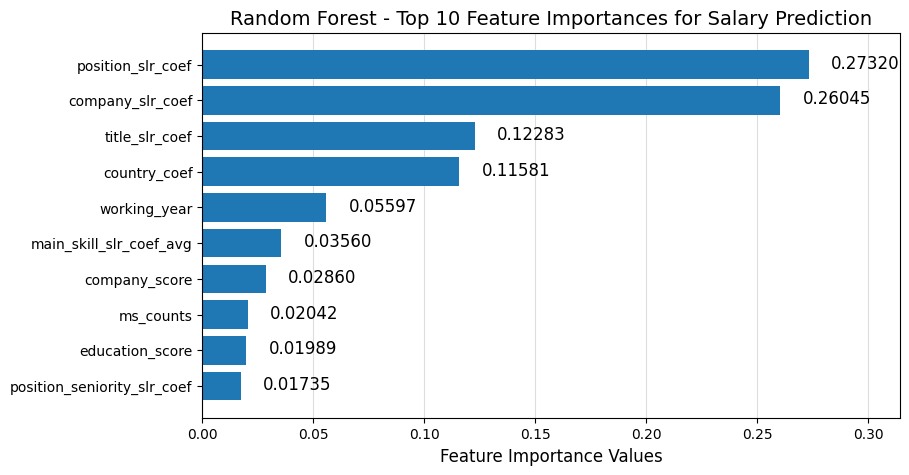

In [240]:
# Show the feature importances of the random forest; only the last run is considered
if x_train.shape[1] < 10:  feat_num = x_train.shape[1]
else:  feat_num = 10
rforest_feat_impr = pd.Series(rforest.feature_importances_, index=salaries.columns[:x_train.shape[1]]).sort_values(ascending=False)[:10]
plt.figure(figsize=(9,5))
plt.barh(rforest_feat_impr.index[::-1], rforest_feat_impr[::-1], zorder=2)
plt.xlim(0.0, rforest.feature_importances_.max()*1.15)
for i in range(len(rforest_feat_impr)):
    plt.text(rforest_feat_impr[i]+0.01, feat_num-i-1.1, "{:.5f}".format(rforest_feat_impr[i]), fontsize=12)
plt.title("Random Forest - Top {} Feature Importances for Salary Prediction".format(feat_num), fontsize=14)
plt.xlabel('Feature Importance Values', fontsize=12)
plt.grid(color='#dddddd', axis='x', zorder=1)
plt.show()

In [241]:
# Results of metrics (all produced results, plus their averages)
if random_state_in_use:
    print("### RESULTS OF METRICS -> RANDOM STATE {} | DROP NA TYPE {} | SUBSET TYPE {} | COLUMN TYPE {} || SIZE {}/{}/{} ###".format(
        random_state, dropna_type, subset_type, column_type, salaries.shape[0], x_train.shape[0], x_test.shape[0]))
else:   print("### RESULTS FOR CUSTOM TRAIN-TEST SETS ###")
mse, rmse, mae, r2, adj_r2 = round(sum(rforest_mse) / len(rforest_mse), 4), \
    round(sum(rforest_rmse) / len(rforest_rmse), 4), \
    round(sum(rforest_mae) / len(rforest_mae), 4), \
    round(sum(rforest_r2) / len(rforest_r2), 6), \
    round(sum(rforest_adj_r2) / len(rforest_adj_r2), 6)
print("MSE: ", rforest_mse, '->', mse)
print("RMSE:", rforest_rmse, '->', rmse)
print("MAE: ", rforest_mae, '->', mae)
print("R2 SCORE:", rforest_r2, '->', r2)
print("ADJUSTED R2 SCORE:", rforest_adj_r2, '->', adj_r2)

### RESULTS OF METRICS -> RANDOM STATE 8 | DROP NA TYPE 1 | SUBSET TYPE 1 | COLUMN TYPE 15 || SIZE 19554/17598/1956 ###
MSE:  [1076985056.5738513, 1048065520.0759088, 1071881048.8662235] -> 1065643875.172
RMSE: [32817.45048863259, 32373.84005761301, 32739.59451285589] -> 32643.6284
MAE:  [22197.546983640084, 21946.14691206544, 22256.829417177916] -> 22133.5078
R2 SCORE: [0.827956279, 0.83257605, 0.828771622] -> 0.829768
ADJUSTED R2 SCORE: [0.826447123, 0.831107419, 0.827269619] -> 0.828275


In [242]:
# Cross validation is executed only once
s_time = time.time()
cross_val = cross_validate(rforest, X, y, cv=cv_fold, return_train_score=True)
print("### CROSS VALIDATION ({}-FOLD) ###".format(cv_fold))
print("FITTING TIME: {} -> {:.8f}".format(cross_val['fit_time'], cross_val['fit_time'].mean()))
print("SCORING TIME: {} -> {:.8f}".format(cross_val['score_time'], cross_val['score_time'].mean()))
print("TRAIN SCORE:  {} -> {:.8f}".format(cross_val['train_score'], cross_val['train_score'].mean()))
print("TEST SCORE:   {} -> {:.8f}".format(cross_val['test_score'], cross_val['test_score'].mean()))     
print("Cross validation was completed in {:.3f} seconds.".format(time.time()-s_time))

### CROSS VALIDATION (10-FOLD) ###
FITTING TIME: [6.11721921 6.08864546 6.28905845 6.11239362 6.05883288 5.99664545
 5.91642356 5.99539995 5.90910864 6.10900426] -> 6.05927315
SCORING TIME: [0.03859115 0.02737093 0.02879906 0.02826595 0.02776456 0.02996659
 0.0285449  0.02821279 0.02900219 0.05861521] -> 0.03251333
TRAIN SCORE:  [0.97589211 0.97599355 0.97517374 0.97547901 0.9750031  0.97565656
 0.97481229 0.97551862 0.97521849 0.97605259] -> 0.97548001
TEST SCORE:   [0.81820817 0.82280682 0.82996279 0.82309821 0.83059261 0.83989443
 0.84344021 0.84358369 0.84269339 0.82087761] -> 0.83151579
Cross validation was completed in 62.836 seconds.


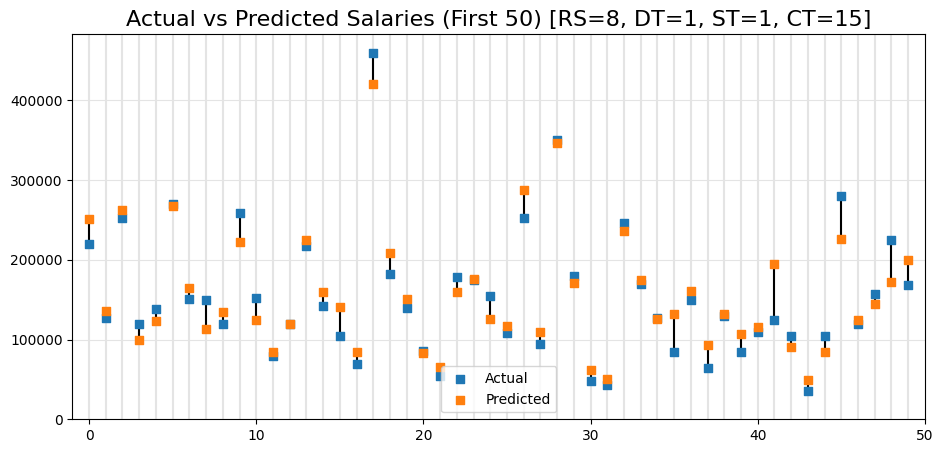

In [243]:
# Compare the predicted salaries against the actual ones in a visualization, for the first 50 salaries of the test set
# Only applicable for the last run of random forest regression
if x_test.shape[0] < 50:  rows = x_test.shape[0]
else:  rows = 50
plt.figure(figsize=(11,5))
plt.axis([-1,rows,0,y_test.iloc[:rows].max()*1.05])
for i in range(rows):
    # print("{:20} | {:8}".format(y_pred[i], y_test.iloc[i]))
    plt.axvline(i, color='#e4e4e4', zorder=2)
plt.scatter(range(rows), y_test.iloc[:rows], marker='s',label='Actual', zorder=4)
plt.scatter(range(rows), y_pred[:rows], marker='s',label='Predicted', zorder=4)
plt.title("Actual vs Predicted Salaries (First {}) [RS={}, DT={}, ST={}, CT={}]".format(
    rows, random_state, dropna_type, subset_type, column_type), fontsize=16)
for i in range(rows):
    plt.axvline(i, ymin=y_test.iloc[i]/(y_test.iloc[:rows].max()*1.05), ymax=y_pred[i]/(y_test.iloc[:rows].max()*1.05), 
                color='black', zorder=3)
plt.legend()
plt.grid(color='#e4e4e4', axis='y', zorder=1)
plt.show()

## Explain the Model with SHAP

In [244]:
# Getting SHAP values may take a long time with Random Forest, especially for test sizes larger than 1000
# A progress bar can appear in the output
shap.initjs()
shap_explainer = shap.Explainer(rforest, x_train)
shap_values = shap_explainer(x_test, check_additivity=False)
print(shap_values.shape)
print(shap_values)
print("\n EXPECTED VALUE:", shap_explainer.expected_value)

### Global Explainability

### SUMMARY OF EXPLAINABILITY WITH SHAP ###


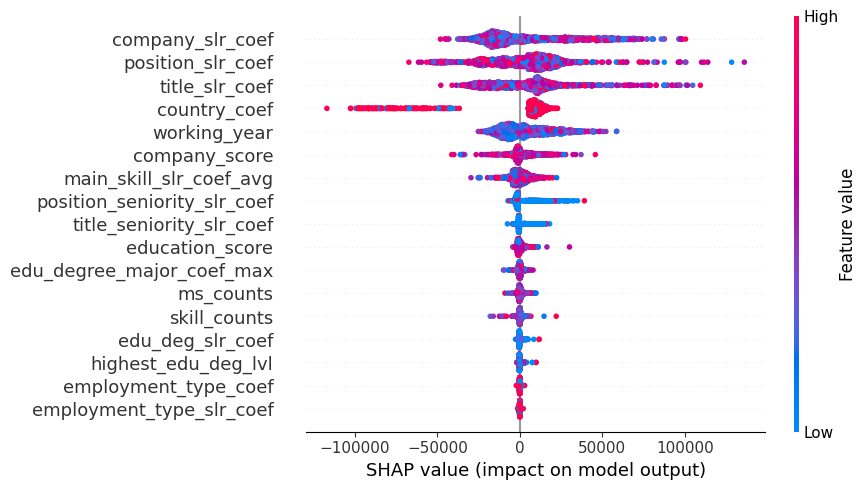

In [245]:
print("### SUMMARY OF EXPLAINABILITY WITH SHAP ###")
# shap.plots.beeswarm(shap_values)
shap.summary_plot(shap_values, x_test, plot_type='dot', plot_size=[9,5])

In [246]:
print("### VISUALIZATION OF FIRST 200 PREDICTIONS ###")
shap.plots.force(shap_values[:200])

### VISUALIZATION OF FIRST 200 PREDICTIONS ###


### MEAN ABSOLUTE VALUES OF SHAP VALUES ###


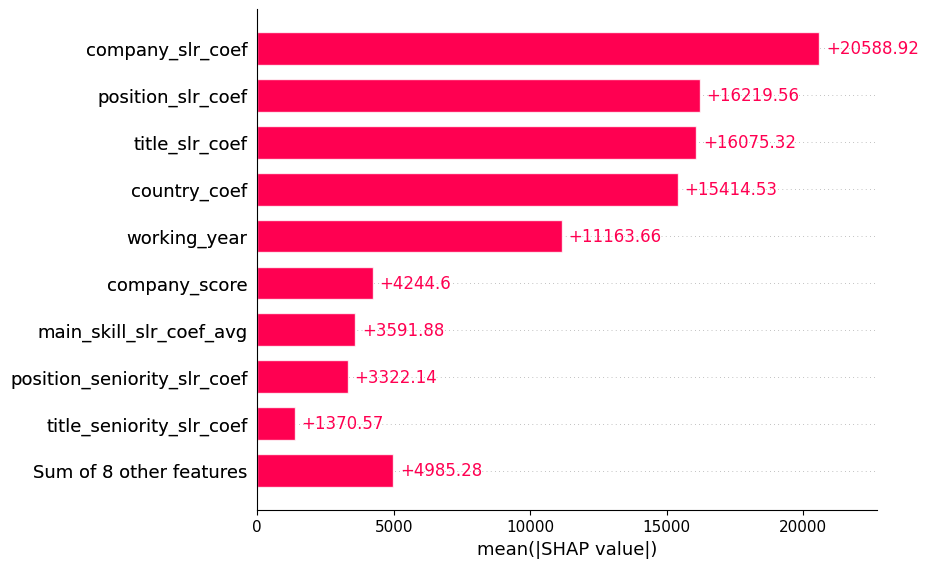

In [247]:
print("### MEAN ABSOLUTE VALUES OF SHAP VALUES ###")
shap.plots.bar(shap_values)

### DEPENDENCY BETWEEN THE FIRST COLUMN & THE BEST INTERACTION ###


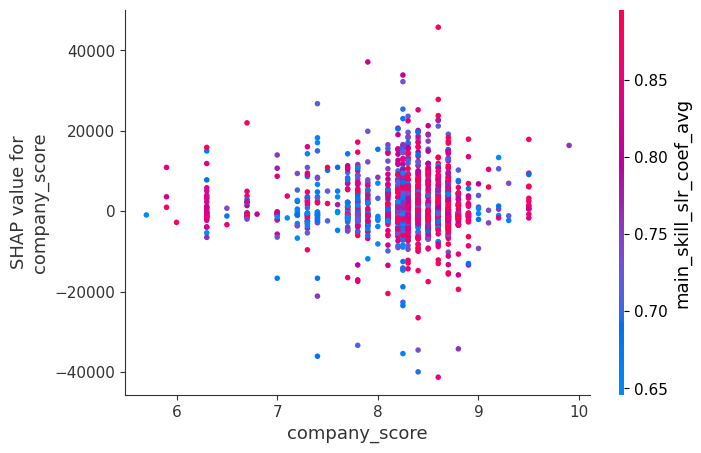

In [248]:
print("### DEPENDENCY BETWEEN THE FIRST COLUMN & THE BEST INTERACTION ###")
shap.dependence_plot(x_train.columns[0], shap_values.values, x_test)

### Local Explainability

### EXPLAINING TEST ROW 333 WITH SHAP ###
PREDICTED VALUE BY ML MODEL = 129420.0000
BASE VALUE = 148336.4298
company_score             =    6.700 -->    2330.7190
working_year              =   16.000 -->    5391.2121
education_score           =    8.401 -->     324.8735
ms_counts                 =    3.000 -->     820.1499
skill_counts              =   17.000 -->    -974.0320
country_coef              =    1.000 -->   12340.0284
title_slr_coef            =    0.399 -->   13302.3266
title_seniority_slr_coef  =    0.488 -->   -2007.1544
position_slr_coef         =    0.400 -->   18684.4515
position_seniority_slr_coef =    0.518 -->   -2428.8602
employment_type_coef      =    0.990 -->     314.8616
employment_type_slr_coef  =    1.000 -->      98.3215
highest_edu_deg_lvl       =    0.500 -->    -193.3687
edu_deg_slr_coef          =    0.657 -->     163.6481
edu_degree_major_coef_max =    0.718 -->   -1636.2017
company_slr_coef          =    0.395 -->    5669.3758
main_skill_slr_coef_avg  

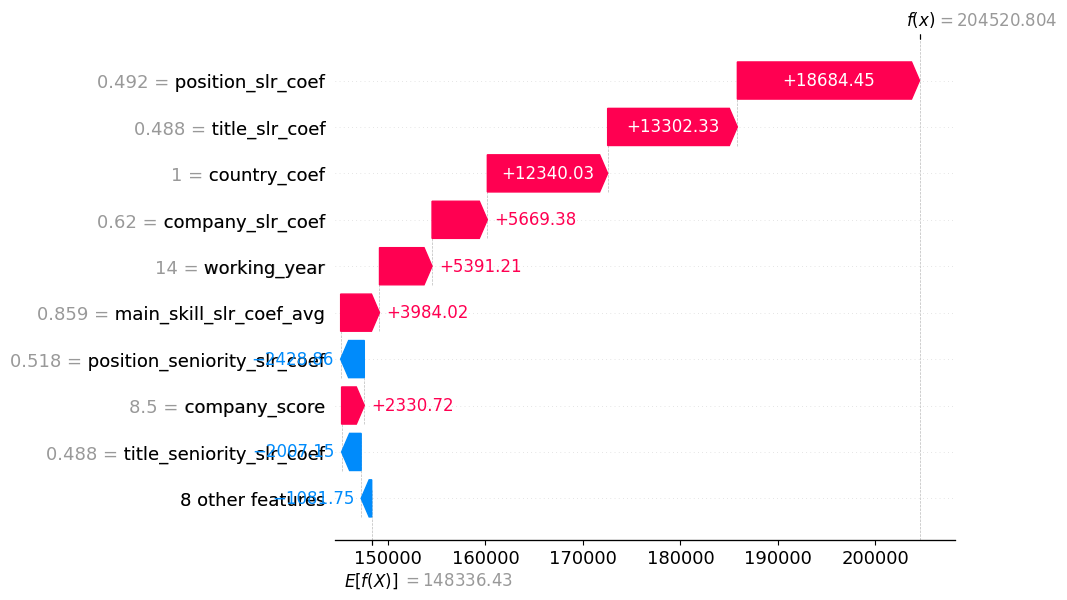

In [249]:
# i = 0
i = random.randint(0, x_test.shape[0]-1)
print("### EXPLAINING TEST ROW {} WITH SHAP ###".format(i))
print("PREDICTED VALUE BY ML MODEL = {:.4f}".format(y_pred[i]))
print("BASE VALUE = {:.4f}".format(shap_values.base_values[i]))
for j in range(x_test.shape[1]):
    print("{:25} = {:8.3f} --> {:12.4f}".format(x_test.columns[j], x_test.iloc[i,j], shap_values.values[i][j]))
print("RESULT VALUE --> {:.4f} + {:.4f} = {:.4f}".format(shap_values.base_values[j], sum(shap_values.values[i]), 
                            shap_values.base_values[j] + sum(shap_values.values[i])))
print("DIFFERENCE --> {:.4f}".format(abs(y_pred[i] - (shap_values.base_values[j] + sum(shap_values.values[i])))))
shap.plots.waterfall(shap_values[i])

In [250]:
print("### EXPLAINING TEST ROW {} WITH SHAP ###".format(i))
shap.plots.force(shap_values[i])

### EXPLAINING TEST ROW 333 WITH SHAP ###


### Local Explainability with Custom Row

In [251]:
def shap_custom_row(x_test_custom):
    x_test_shap = shap_explainer(x_test_custom, check_additivity=False)
    print("BASE VALUE = {:.4f}".format(x_test_shap.base_values[0]))
    for j in range(x_test_custom.shape[1]):
        print("{:25} = {:8.3f} --> {:12.4f}".format(x_test_custom.columns[j], x_test_custom.iloc[0,j], x_test_shap.values[0][j]))
    print("RESULT VALUE --> {:.4f} + {:.4f} = {:.4f}".format(x_test_shap.base_values[0], sum(x_test_shap.values[0]), 
                                x_test_shap.base_values[0] + sum(x_test_shap.values[0])))

In [252]:
print("### EXPLAINING A CUSTOM ROW WITH SHAP ###".format(i))
if column_type not in [1, 3]:
    print("Local explanability with custom row is not implemented yet with column type", column_type)
elif column_type == 1:
    x_test_custom = pd.DataFrame({0: np.array([8.6, 11.0, 9.0, 14.0, 22.0])}, index=x_test.columns).T
    shap_custom_row(x_test_custom)
elif column_type == 3:
    x_test_custom = pd.DataFrame({0: np.array([8.2, 7.0, 8.7, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.0, 0.0, 1.0, 0.0, 0.0,
                         0.0, 0.0, 1.0, 1.0, 0.0, 0.0])}, index=x_test.columns).T
    shap_custom_row(x_test_custom)

### EXPLAINING A CUSTOM ROW WITH SHAP ###
Local explanability with custom row is not implemented yet with column type 15


## Explain the Model with LIME

In [253]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(x_train.values, feature_names=salaries.columns, 
                                                        class_names=['amount_usd'], verbose=True, mode='regression')

In [254]:
# i = 0
i = random.randint(0, x_test.shape[0]-1)
print("### EXPLAINING TEST ROW {} WITH LIME ###".format(i))
print("PREDICTED VALUE BY ML MODEL = {:.4f}".format(y_pred[i]))
exp = lime_explainer.explain_instance(x_test.iloc[i], rforest.predict, num_features=10)
exp.show_in_notebook(show_table=True)
exp_list = exp.as_list()
exp_map = exp.as_map()
print("MIN VALUE:", exp.min_value, "  MAX VALUE:", exp.max_value)
total = 0.0
for j in range(10):
    print("{:35} | {:8.3f}  -->  {}".format(exp_list[j][0], x_test.iloc[i,exp_map[0][j][0]], exp_list[j][1]))
    total += exp_list[j][1]
print("PREDICTION LOCAL --> {:.4f} + {:.4f} = {:.4f}".format(exp.intercept[1], total, exp.intercept[1] + total))

### EXPLAINING TEST ROW 593 WITH LIME ###
PREDICTED VALUE BY ML MODEL = 242380.0000
Intercept 171321.04212007928
Prediction_local [192665.75634353]
Right: 242380.0


MIN VALUE: 47700.0   MAX VALUE: 330340.0
title_slr_coef > 0.54               |    0.642  -->  36032.154029495374
position_slr_coef > 0.56            |    0.647  -->  27517.761777823947
working_year <= 6.00                |    6.000  -->  -19415.584223494927
position_seniority_slr_coef <= 0.52 |    0.518  -->  -9036.44102942659
0.54 < company_slr_coef <= 0.68     |    0.676  -->  -4233.170090210375
title_seniority_slr_coef <= 0.49    |    0.488  -->  -3619.022508326204
0.71 < main_skill_slr_coef_avg <= 0.80 |    0.800  -->  -2931.384068934028
edu_deg_slr_coef <= 0.66            |    0.657  -->  -2797.204413631695
11.00 < ms_counts <= 16.00          |   16.000  -->  -1916.30643311338
education_score > 9.50              |   10.000  -->  1743.9111832654269
PREDICTION LOCAL --> 171321.0421 + 21344.7142 = 192665.7563


### Local Explainability with Custom Row

In [255]:
def lime_custom_row(x_test_custom):
    exp = lime_explainer.explain_instance(x_test_custom.iloc[0], rforest.predict, num_features=x_test.shape[1])
    exp_list = exp.as_list()
    exp_map = exp.as_map()
    total = 0.0
    print("MODE:", exp.mode)
    print("CLASS NAMES:", exp.class_names)
    print("MIN VALUE:", exp.min_value, "  MAX VALUE:", exp.max_value)
    for j in range(x_test.shape[1]):
        print("{:35} | {:8.3f}  -->  {}".format(exp_list[j][0], x_test_custom.iloc[0,exp_map[0][j][0]], exp_list[j][1]))
        total += exp_list[j][1]
    print("PREDICTION LOCAL --> {:.4f} + {:.4f} = {:.4f}".format(exp.intercept[1], total, exp.intercept[1] + total))

In [256]:
print("### EXPLAINING A CUSTOM ROW WITH LIME ###".format(i))
if column_type not in [1, 3]:
    print("Local explanability with custom row is not implemented yet with column type", column_type)
elif column_type == 1:
    x_test_custom = pd.DataFrame({0: np.array([8.6, 11.0, 9.0, 14.0, 22.0])}, index=x_test.columns).T
    lime_custom_row(x_test_custom)
elif column_type == 3:
    x_test_custom = pd.DataFrame({0: np.array([9.2, 12.0, 8.4, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.0, 1.0, 1.0, 0.0, 0.0,
                             0.0, 0.0, 1.0, 1.0, 0.0, 1.0])}, index=x_test.columns).T
    lime_custom_row(x_test_custom)

### EXPLAINING A CUSTOM ROW WITH LIME ###
Local explanability with custom row is not implemented yet with column type 15
